Original surface (with NaNs):
[[  nan   nan 0.188 0.196]
 [0.207 0.204   nan 0.214]
 [0.224 0.222 0.224   nan]]
NaNs count: 4

Filled surface:
[[0.191 0.188 0.188 0.196]
 [0.207 0.204 0.205 0.214]
 [0.224 0.222 0.224 0.235]]
NaNs remaining: 0


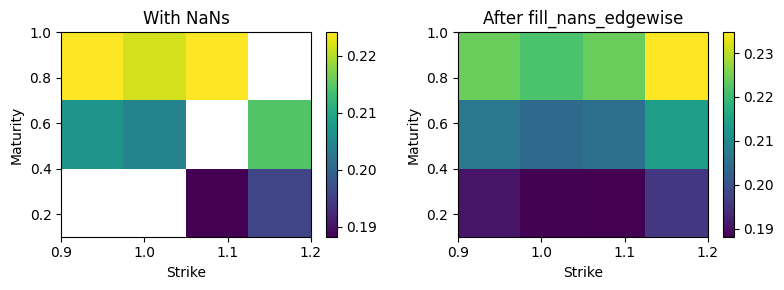

In [6]:
# example_fill_demo.py
import numpy as np
import matplotlib.pyplot as plt
import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
from generation.surface_generation import fill_nans_edgewise

np.set_printoptions(precision=3, suppress=True)

# coordinates (physical)
strikes = np.array([0.9, 1.0, 1.1, 1.2])        # 4 strikes
maturities = np.array([0.1, 0.5, 1.0])          # 3 maturities

# build a simple surface: base + smile + term
# surface will be (3 maturities × 4 strikes)
K, T = np.meshgrid(strikes, maturities)
surface = 0.18 + 0.25*(K - 1.0)**2 + 0.06*np.log1p(T)

# introduce some NaNs (simulate missing/failed points)
surface_with_nans = surface.copy()
surface_with_nans[0, 0] = np.nan  # (T=0.1, K=0.9)
surface_with_nans[0, 1] = np.nan  # (T=0.1, K=1.0)
surface_with_nans[2, 3] = np.nan  # (T=1.0, K=1.2)
surface_with_nans[1, 2] = np.nan  # (T=0.5, K=1.1)

print("Original surface (with NaNs):")
print(surface_with_nans)
print("NaNs count:", np.isnan(surface_with_nans).sum())

# fill using physical coords (and correct orientation)
filled = fill_nans_edgewise(surface_with_nans.T, strikes=strikes, maturities=maturities).T

print("\nFilled surface:")
print(filled)
print("NaNs remaining:", np.isnan(filled).sum())

# quick visual comparison
fig, ax = plt.subplots(1, 2, figsize=(8, 3))
im0 = ax[0].imshow(surface_with_nans, origin='lower', cmap='viridis',
                   extent=[strikes[0], strikes[-1], maturities[0], maturities[-1]],
                   aspect='auto')
ax[0].set_title('With NaNs')
ax[0].set_xlabel('Strike'); ax[0].set_ylabel('Maturity')
plt.colorbar(im0, ax=ax[0])

im1 = ax[1].imshow(filled, origin='lower', cmap='viridis',
                   extent=[strikes[0], strikes[-1], maturities[0], maturities[-1]],
                   aspect='auto')
ax[1].set_title('After fill_nans_edgewise')
ax[1].set_xlabel('Strike'); ax[1].set_ylabel('Maturity')
plt.colorbar(im1, ax=ax[1])

plt.tight_layout()
plt.show()

In [1]:
from datetime import datetime
import os
import pickle
import numpy as np

import sys, os
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

from generation.surface_generation import generate_surfaces, SimulationConfig
from models.framework import DeepONet, Trainer, ModelEvaluator

# ============================================================
# 1️⃣ Generate synthetic Rough Bergomi IV surfaces
# ============================================================

cfg = SimulationConfig(M=50000, n=500, T_max=2.0, S0=1.0, G=2)
surfaces = generate_surfaces(
    num_sets=1,
    forward_curves_per_set=10,
    cfg=cfg,
    seed=4235,
    randomize_grid=True,
)

#Load surfaces from pickle file
# with open('data/surfaces_progress.pkl', 'rb') as f:
#    surfaces = pickle.load(f)
#    surfaces = surfaces['surfaces']
# print(f"Loaded {len(surfaces)} surfaces from pickle file")

[Done] Saved final dataset with 20 surfaces to:
      → data\2025-10-30\surfaces_10-10-23.pkl
      → data/surfaces_progress.pkl


In [2]:
surfaces[0]["iv_surface"]

array([[0.2575634 , 0.24834464, 0.23945584, 0.2308852 , 0.22262131,
        0.2187368 , 0.22063089, 0.23422708, 0.24287571, 0.25184369,
        0.2611428 ],
       [0.2598954 , 0.25060703, 0.24165061, 0.22490804, 0.21986169,
        0.21769469, 0.21879484, 0.22666496, 0.22999485, 0.24246504,
        0.24612424],
       [0.22988066, 0.22817244, 0.22647691, 0.21149111, 0.20701421,
        0.20481174, 0.20628114, 0.21382486, 0.21688816, 0.22756887,
        0.23295869],
       [0.19132833, 0.18903879, 0.18677664, 0.17678437, 0.17357302,
        0.1719847 , 0.17305662, 0.17805089, 0.18018563, 0.18738885,
        0.19099397],
       [0.25134889, 0.2322345 , 0.22410278, 0.21409241, 0.21159199,
        0.21027465, 0.21244382, 0.21587607, 0.2175196 , 0.22353073,
        0.22712802],
       [0.25076744, 0.23552571, 0.2283248 , 0.21812287, 0.21548648,
        0.2141649 , 0.2167121 , 0.22077595, 0.22223321, 0.2277938 ,
        0.23138617],
       [0.25688474, 0.24175135, 0.23482916, 0.22536417, 0.

In [3]:
surfaces[0]["price_surface"]

array([[0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 7.46510706e-05,
        1.58856195e-03, 1.23199463e-02, 5.79453769e-03, 6.30748925e-05,
        1.81707395e-05, 0.00000000e+00, 0.00000000e+00],
       [0.00000000e+00, 2.23520075e-06, 3.73933733e-05, 2.54876369e-03,
        1.05288733e-02, 2.96629614e-02, 2.06332614e-02, 2.58607854e-03,
        1.37234259e-03, 1.77420465e-04, 4.47637014e-05],
       [0.00000000e+00, 1.89747461e-06, 4.66903426e-05, 2.83353117e-03,
        1.12284759e-02, 3.06717506e-02, 2.16673435e-02, 2.93939791e-03,
        1.59820302e-03, 2.16023967e-04, 6.32192975e-05],
       [0.00000000e+00, 5.59072530e-06, 9.20672811e-05, 3.97038390e-03,
        1.37784559e-02, 3.44086280e-02, 2.51810969e-02, 4.12516850e-03,
        2.37161305e-03, 3.73557601e-04, 1.18641026e-04],
       [8.32169550e-05, 6.48987160e-04, 2.21741814e-03, 1.67869522e-02,
        3.46292690e-02, 6.08352495e-02, 5.17534996e-02, 1.88712972e-02,
        1.40083183e-02, 5.27652661e-03, 2.94431808e-

In [2]:
# ============================================================
# Train the model
# ============================================================

# Prepare data loaders (no normalization needed as inputs are already well-scaled)
train_loader, val_loader, branch_dim = DeepONet.prepare_data(surfaces, batch_size=256, normalize=False)

# Initialize and train model
model = DeepONet(branch_in_dim=branch_dim, trunk_in_dim=2, latent_dim=64, hidden_dim=64)
model._build_networks()

trainer = Trainer(model, train_loader, val_loader, lr=1e-3)
trainer.fit(epochs=20)

Prepared data → 352000 train / 88000 val samples
Branch dim: 11, Trunk dim: 2


Epoch 01: train_rmse=0.036576, val_rmse=0.024080


Epoch 02: train_rmse=0.021572, val_rmse=0.020268


Epoch 03: train_rmse=0.018714, val_rmse=0.017756


Epoch 04: train_rmse=0.017421, val_rmse=0.017217


...

Epoch 16: train_rmse=0.013244, val_rmse=0.013999


Epoch 17: train_rmse=0.012939, val_rmse=0.015399


Epoch 18: train_rmse=0.012785, val_rmse=0.013443


Epoch 19: train_rmse=0.012472, val_rmse=0.012634


Epoch 20: train_rmse=0.012528, val_rmse=0.011270


MSE stats:
  mse_mean: 0.00012391385090562788
  mse_std: 0.00026822135455983697
  mse_max: 0.002329194952531655
  rmse: 0.01113165984503784
  mae: 0.008034484190492401
  max_abs_error: 0.04826173383263033
  max_error_location: {'maturity_index': 0, 'strike_index': 0, 'strike': 0.5202236996485117, 'maturity': 0.10007508435134681}
MSE stats:
  mse_mean: 0.0001832786517278427
  mse_std: 0.0003317902613869475
  mse_max: 0.0020555804220005938
  rmse: 0.013538044605032246
  mae: 0.009664990905206722
  max_abs_error: 0.04533850926089866
  max_error_location: {'maturity_index': 0, 'strike_index': 3, 'strike': 0.8038705469376579, 'maturity': 0.01}
MSE stats:
  mse_mean: 0.0001832786517278427
  mse_std: 0.0003317902613869475
  mse_max: 0.0020555804220005938
  rmse: 0.013538044605032246
  mae: 0.009664990905206722
  max_abs_error: 0.04533850926089866
  max_error_location: {'maturity_index': 0, 'strike_index': 3, 'strike': 0.8038705469376579, 'maturity': 0.01}
MSE stats:
  mse_mean: 8.621410205075

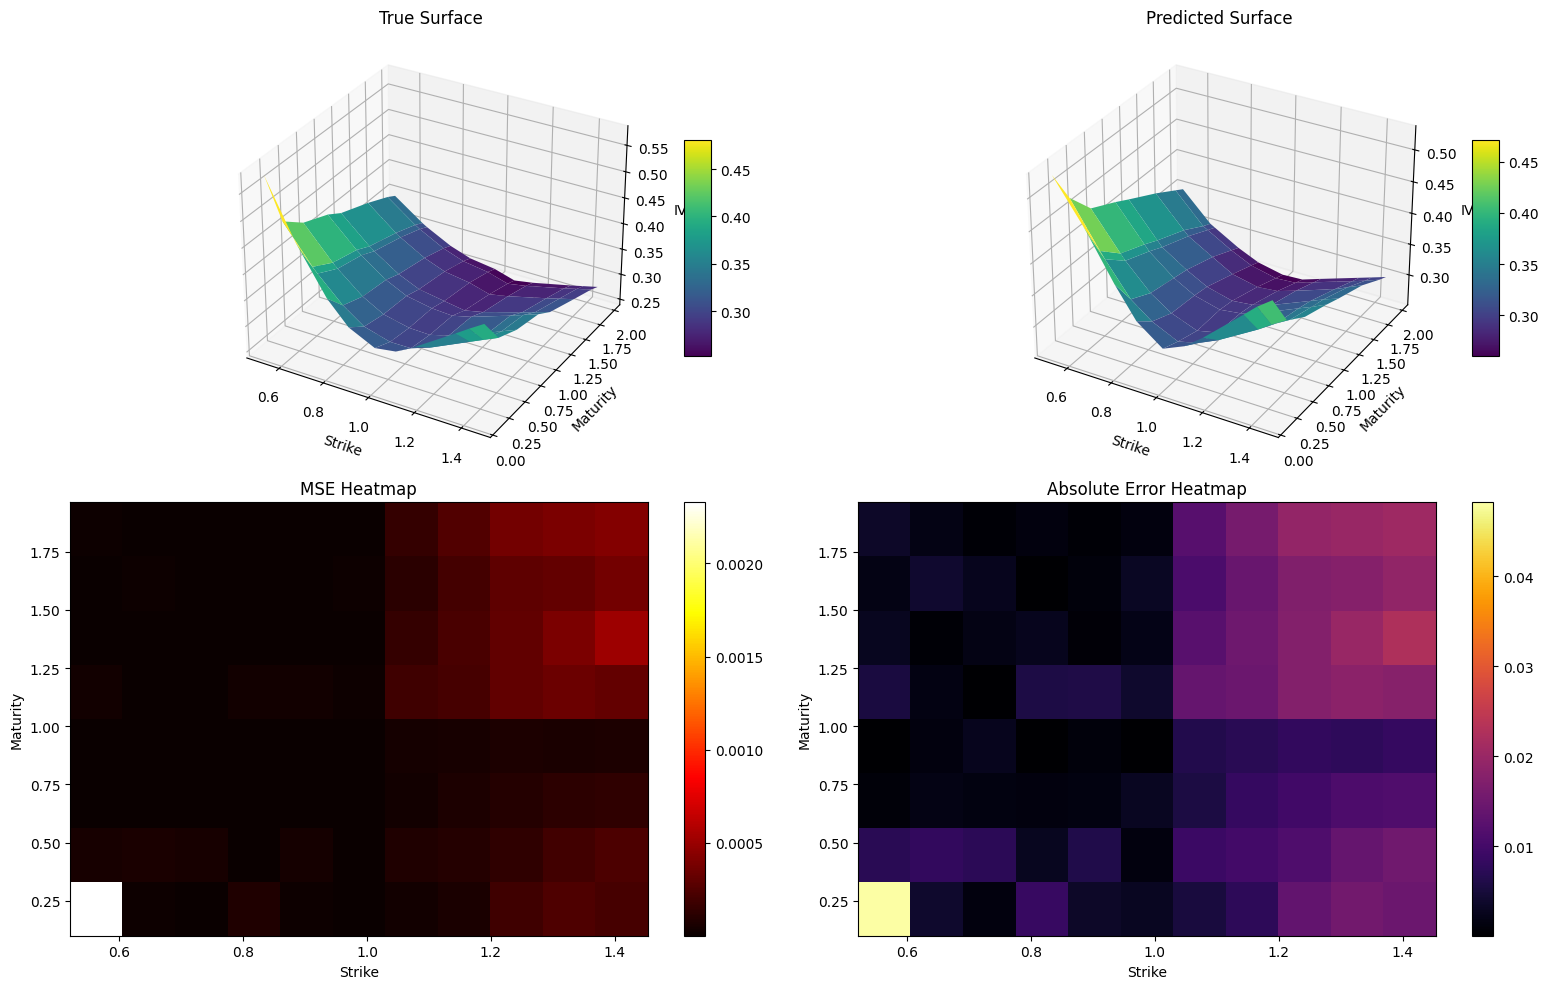

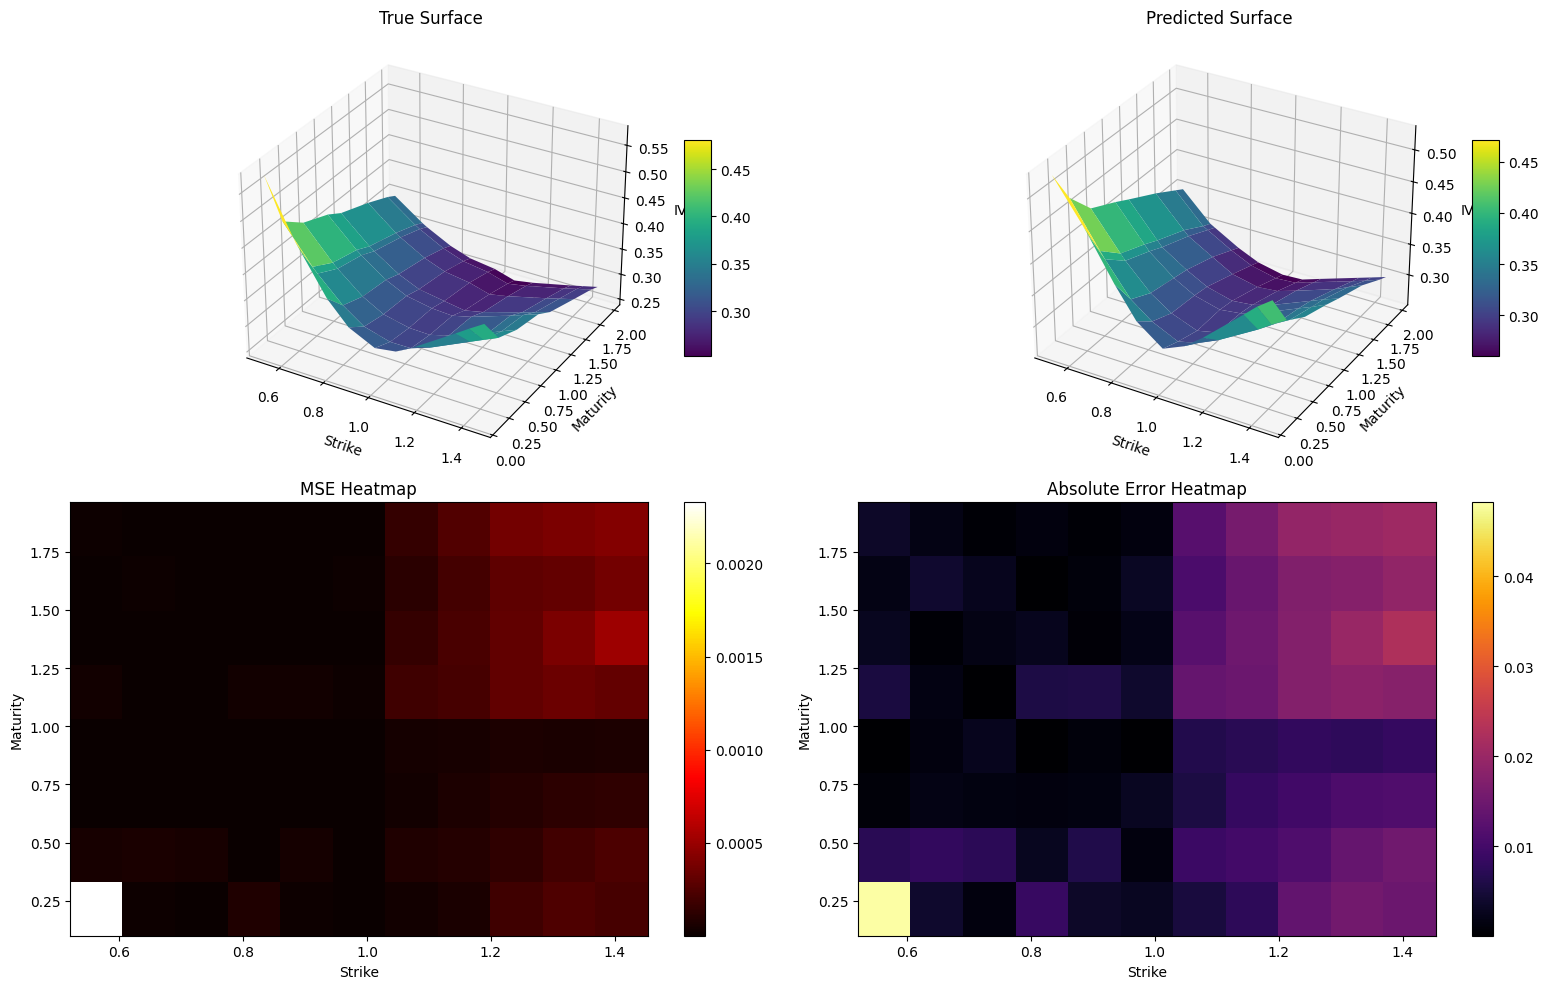

In [3]:
# ============================================================
# Evaluate the model
# ============================================================

# Create evaluator (no normalization needed)
evaluator = ModelEvaluator(model)

# Select test samples for visualization
test_samples = surfaces[-5:]  # Use last 5 surfaces as test samples

# Create directory for evaluation plots
save_dir = os.path.join('data', datetime.now().strftime('%Y-%m-%d'), 'evaluation')
os.makedirs(save_dir, exist_ok=True)

# Generate evaluation plots
evaluator.evaluate_samples(test_samples, save_path=save_dir)
print(f"Evaluation plots saved to {save_dir}")

# Show an example plot in the notebook
evaluator.plot_evaluation(test_samples[0])  # Display first test sample's evaluation